# «Исследование паттернов покупательского поведения методами визуализации и снижения размерности»

**Цель** 

- Провести комплексный разведочный анализ данных (EDA) для выявления скрытых закономерностей и аномалий в поведении клиентов.
- Формирование гипотез и визуальный анализ взаимосвязей между характеристиками клиентов и их покупательской активностью.
- Снижение размерности признакового пространства (PCA, t-SNE) для визуализации структуры данных и выявления естественных кластеров потребителей.
- Интерпретация полученных сегментов и описание характерных профилей потребления для каждой группы.
- Разработка бизнес-рекомендаций по оптимизации маркетинговых активностей и программ лояльности на основе выявленных инсайтов.

**Данные**

Дата сет "Customer Shopping Behaviour Analysis"

https://www.kaggle.com/datasets/wardabilal/customer-shopping-behaviour-analysis/data

**Описание данных**

Данный набор данных позволяет получить полное представление о покупательском поведении потребителей в розничной торговле. Он позволяет получить полезные сведения о том, как потребители совершают покупки, тратят деньги и принимают решения, сочетая демографические данные с информацией о покупках.

В набор данных включены такие переменные, как возраст и пол клиента, приобретенные товары, сумма покупки, способы оплаты, использование скидок и частота покупок. Изучение этих характеристик позволяет выявить закономерности в потребительских предпочтениях, моделях расходов и влиянии рекламных акций на покупательское поведение.

Для таких проектов, как аналитика розничной торговли, сегментация клиентов и принятие корпоративных решений, этот набор данных идеально подходит для разведочного анализа данных (EDA), визуализации данных и анализа данных. Он особенно полезен для аналитиков, которые хотят попрактиковаться в получении аналитических выводов и использовании данных для представления информации, а также для новичков, желающих получить практический опыт работы с реальными данными о потребителях.

### Тех часть

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
# Только для известных предупреждений t-SNE
warnings.filterwarnings("ignore", category=FutureWarning, module="TSNE")

### EDA

#### Обзор структуры данных

In [30]:
# Загрузим данные
df = pd.read_csv('shopping_behavior_updated.csv')

In [31]:
# Посмотрим сдержание первых 5 строк
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually


**Описание данных (Dataset Features)**

- Customer ID — Уникальный идентификатор покупателя.
- Age — Возраст пользователя.
- Gender — Пол (Male/Female).
- Item Purchased — Название купленного товара.
- Category — Категория товара (Clothing, Footwear, Outerwear, Accessories).
- Purchase Amount (USD) — Сумма транзакции в долларах.
- Location — Штат/регион, где совершена покупка.
- Size — Размер изделия (S, M, L, XL).
- Color — Цвет товара.
- Season — Сезон покупки (Spring, Summer, Fall, Winter).
- Review Rating — Оценка товара покупателем (от 1 до 5).
- Subscription Status — Наличие активной подписки (Yes/No).
- Discount Applied — Была ли применена скидка при покупке (Yes/No).
- Previous Purchases — Количество предыдущих покупок клиента в этом магазине.
- Payment Method — Способ оплаты (Venmo, Cash, Credit Card, PayPal и др.).
- Frequency of Purchases — Частота покупок (Weekly, Bi-weekly, Fortnightly, Monthly и др.).

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Discount Applied        3900 non-null   object 
 13  Previous Purchases      3900 non-null   int64  
 14  Payment Method          3900 non-null   

Имеем 16 столбцов и 3900 строк взаимодействий.

In [33]:
# Подсчитаем количество пропущенных значений в каждом поле
missing_value_cnt = df.isnull().sum()
missing_value_cnt

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Данные очень чистые - пропусков нет.

In [34]:
# Проверим на наличие дубликатов
duplicates_count = df.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_count}")

Количество полных дубликатов: 0


In [35]:
# Удаляем ID, так как он не несет полезной информации для анализа
df = df.drop('Customer ID', axis=1)

Дубликатов тоже нет.

#### Обзор содержания

In [36]:
# Посмотрим на распределение числовых данных
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


- Всего транзакций 3900.
- Возраст полупателя от 18 до 70 лет.
- Сумма каждой транзакции — от 20 до 100 долларов, при среднем значении около 60 долларов.
- Рейтинг товаров лежит в диапазоне от 2,5 до 5, причём наблюдается явное смещение в сторону высоких оценок (мало низких рейтингов).
- Количество предыдущих покупок у клиентов — от 1 до 50, медианное значение составляет 25.
- Несмотря на правдоподобные характеристики, по ряду косвенных признаков можно предположить, что данные являются синтетическими:
    - слишком «ровные» границы значений (например, ровно от 20 до 100 USD),
    - отсутствие выбросов или аномалий, типичных для реальных пользовательских данных,
    - искусственное смещение распределений (например, рейтингов).
    - Тем не менее, такие данные могут адекватно отражать общие закономерности реального поведения, особенно если использовались качественные методы генерации.

In [37]:
# Проанализируем категориальные данные
df.describe(include=['object'])

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Discount Applied,Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,2223,677,584


- В данных представлены два гендера, при этом мужчин значительно больше, чем женщин.
- Ассортимент включает 25 различных товаров.
- Указано 50 локаций магазинов.
- Присутствуют данные за все четыре сезона года, причём весна оказывается наиболее популярным временем для покупок.
- Подавляющее большинство покупок совершается без подписки и без скидки: клиенты с подпиской или со скидками встречаются кратно реже.

#### Анализ методами визуализации

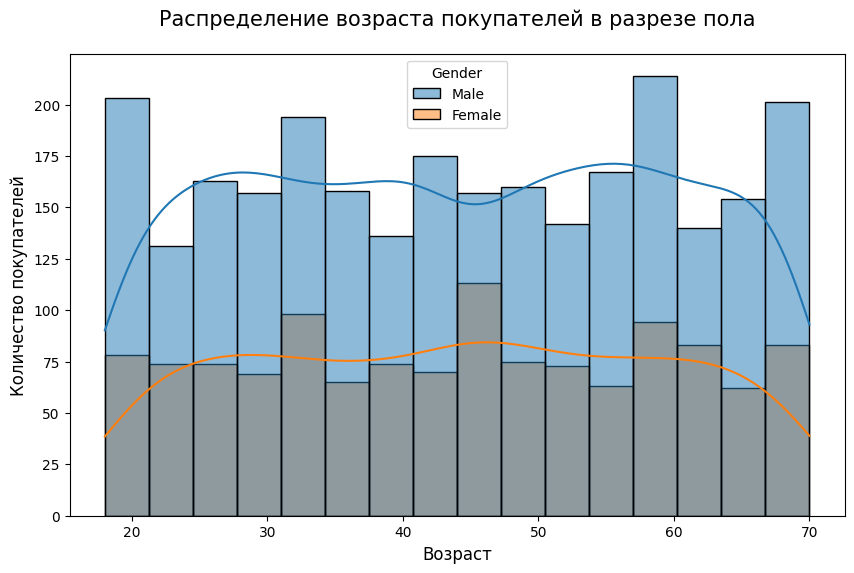

In [38]:
# Проанализируем распределение по возрасту и полу покупателей
# Устанавливаем размер графика
plt.figure(figsize=(10, 6))

# Рисуем график
sns.histplot(
    x='Age',
    hue='Gender',
    data=df,
    kde=True
    )

# Добавляем заголовок и подписи
plt.title('Распределение возраста покупателей в разрезе пола', fontsize=15, pad=20)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Количество покупателей', fontsize=12)
plt.show()

- Покупателями являются преимущественно мужчины — их почти в два раза больше, чем женщин. Такой дисбаланс выглядит необычно для типичного розничного рынка и требует дополнительного анализа.
- Распределение покупателей по возрасту имеет форму плато: оно нарастает от 18 до 25 лет, остаётся относительно стабильным в среднем возрасте и постепенно снижается от 65 до 70 лет.
- У аномалии численного преимущества мужчин может быть несколько причин:
    - Специфика ассортимента: магазины специализируются преимусщественно на товарах, востребованных у мужчин.
    - Географическое расположение: часть торговых точек может находиться в регионах с высокой концентрацией мужского населения, например, в районах с развитой добывающей или обрабатывающей промышленностью, где широко применяется вахтовый метод работы.
    - Близость к промышленным объектам: магазины могут располагаться рядом с крупными заводами, стройками или логистическими центрами, где занято преимущественно мужское население.

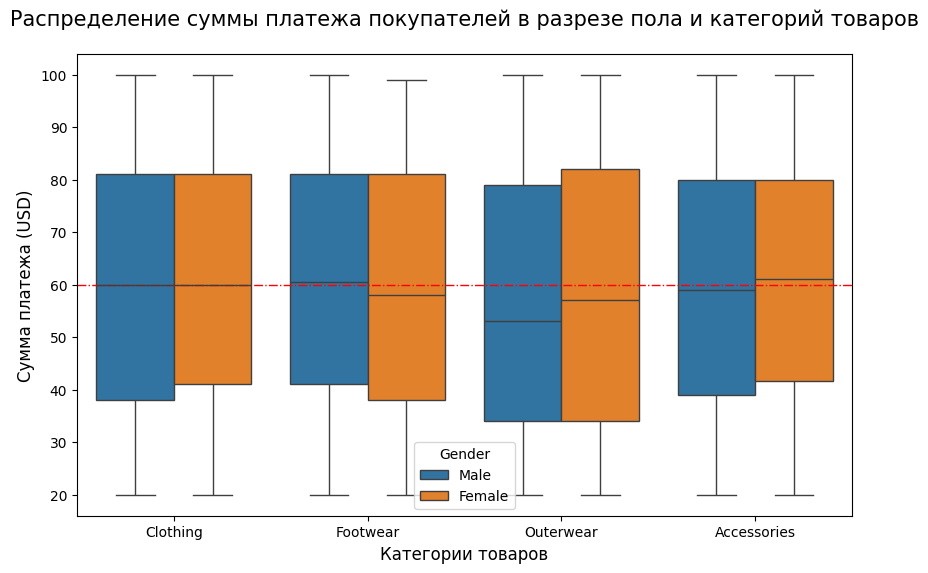

In [39]:
# Посмотрим на распределение суммы платежа покупателей в разрезе пола и категорий товаров
# Устанавливаем размер графика
plt.figure(figsize=(10, 6))

# Рисуем график
sns.boxplot(
    data=df,
    x='Category',
    y='Purchase Amount (USD)',
    hue='Gender'
)

# Добавляем горизонтальную линию на уровне 60 USD
plt.axhline(y=60, color='red', linestyle='-.', linewidth=1, label='Медиана ≈ 60 USD')

# Добавляем заголовок и подписи
plt.title('Распределение суммы платежа покупателей в разрезе пола и категорий товаров', fontsize=15, pad=20)
plt.xlabel('Категории товаров', fontsize=12)
plt.ylabel('Сумма платежа (USD)', fontsize=12)
plt.show()

- Все четыре категории товаров — одежда, обувь, верхняя одежда и аксессуары — имеют схожие ценовые характеристики:
    - их медианные значения близки к общей медиане по всему датасету (60 USD),
    - выбросов нет,
    - основная масса покупок сосредоточена в диапазоне от 25-го перцентиля (35 USD) до 75-го перцентиля (82 USD).
- Особенности:
    - Одежда: у женщин нижний квартиль (Q1) расположен выше, чем у мужчин. Это означает, что 75 % женских покупок начинаются с более высокой ценовой отметки, чем у мужчин.
    - Обувь: зеркально относительно одежды, 75 % мужчин предпочитают обувь с более высокой ценовой отметки, тогда как женщины в среднем склонны к более бюджетным вариантам.
    - Верхняя одежда: здесь наблюдается наибольший разброс цен.
        - Медиана для мужчин — 55 USD, для женщин — 57 USD.
        - Разброс, скорее всего, объясняется широким ассортиментом: от лёгких курток до тяжёлых зимних пальто, а не различиями в качестве. То есть причина — разница в назначении и сезонности, а не в ценовой политике или премиальности.
    - Аксессуары: женщины предпочитают более дорогие товары, тогда как мужчины — более дешёвые.
    - Товары дороже 75-го перцентиля (81 USD) встречаются значительно реже. Вероятно, они относятся к нишевому сегменту с ограниченным спросом из-за высокой цены.
    - Товары дешевле 25-го перцентиля (35 USD) также малопопулярны. Возможно, они воспринимаются как подозрительно дешёвые или низкокачественные, что снижает доверие покупателей.
- Общий вывод: поведение покупателей чётко отражает стремление к «золотой середине»:
люди одинаково избегают как слишком дешёвых, так и явно дорогих товаров, предпочитая решения из центрального ценового диапазона.
Это указывает на рациональное потребительское поведение, ориентированное на баланс между ценой и ожидаемым качеством.

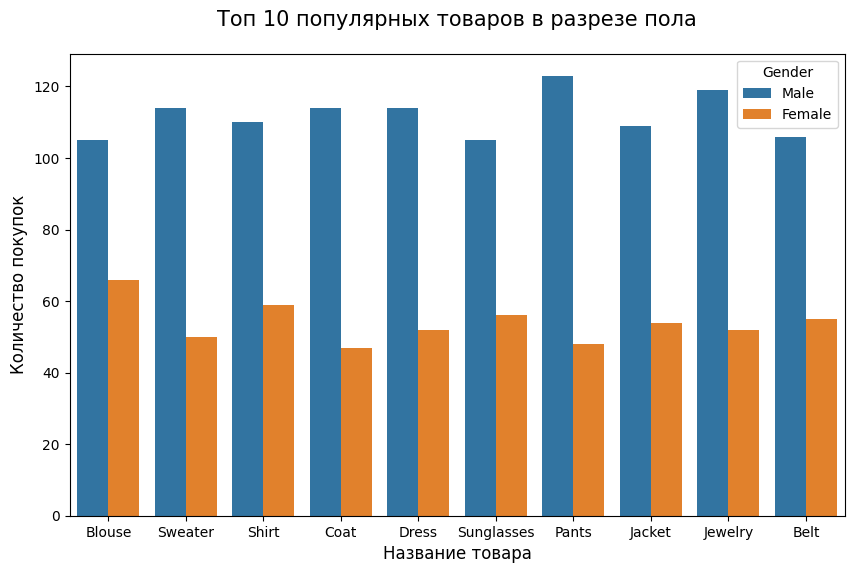

Category
Clothing       841
Accessories    493
Outerwear      324
Name: count, dtype: int64


In [40]:
# Попытаемся понять почему мужчины являются более частыми покупателями
# Выберем топ 10 наиболее пополярных товаров

top10 = df['Item Purchased'].value_counts(ascending=False).head(10).index

# Создаем маску для фильтрации данных
mask = df['Item Purchased'].isin(top10)

# Устанавливаем размер графика
plt.figure(figsize=(10, 6))

# Рисуем график
sns.countplot(
    x='Item Purchased',
    hue='Gender',
    data=df[mask]
    )

# Добавляем заголовок и подписи
plt.title('Топ 10 популярных товаров в разрезе пола', fontsize=15, pad=20)
plt.xlabel('Название товара', fontsize=12)
plt.ylabel('Количество покупок', fontsize=12)
plt.show()

print(df[mask]['Category'].value_counts())

- Топ 10 товаров 
    - Состоит преимущественно из одежды, что согласуется с уже известной информацией.
    - На втором месте — аксессуары, что вызывает интерес: возможно, популярные магазины расположены рядом с производственными центрами или имеют выгодные контракты на поставку, что делает эти товары особенно доступными.
    - Обувь отсутствует в топе, что указывает на её наименьшую частоту покупок среди всех категорий.
- Мужчины чаще всего покупают брюки (что логично) и украшения (на первый взгляд странно, но может быть объяснено, например, подарочными покупками или спецификой ассортимента).
- Женщины чаще выбирают кофточки (ожидаемо) и рубашки (также объяснимо — универсальная базовая одежда).
- Представленные данные не позволяют объяснить, почему мужчины фигурируют как покупатели чаще женщин, и являются как покупателями таких типично женских товаров, как блузки и платья. 

In [41]:
# Отобразим карту продаж, выведем информацию по сумме покупок и их количеству
# Создаем словарь с кодами штатов
state_codes = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# Слелаем датафрейм для карты
df_map = df.loc[:, ['Purchase Amount (USD)', 'Location']]
# Добавляем столбец с кодами штатов
df_map['StateCode'] = df_map['Location'].map(state_codes)

# Отображаем карту по сумме покупок
state_data = df_map.groupby(['Location', 'StateCode'])['Purchase Amount (USD)'].sum().reset_index()

# Устанавливаем размер графика
plt.figure(figsize=(10, 6))

fig = px.choropleth(
    state_data,
    locations='StateCode',      # Столбец с кодами (KY, CA, NY...)
    locationmode="USA-states",  # Указываем, что карта — это штаты США
    color='Purchase Amount (USD)', # Что будет влиять на цвет
    hover_name='Location',      # Что показывать при наведении
    scope="usa",                # Ограничиваем карту только США
    title='Общая сумма покупок по штатам',
    labels={'Purchase Amount (USD)': 'Сумма продаж, $'} 
)

fig.show()

# Отображаем карту по количеству покупок
state_data = df_map.groupby(['Location', 'StateCode'])['Purchase Amount (USD)'].count().reset_index()

# Устанавливаем размер графика
plt.figure(figsize=(10, 6))

fig = px.choropleth(
    state_data,
    locations='StateCode',      # Столбец с кодами (KY, CA, NY...)
    locationmode="USA-states",  # Указываем, что карта — это штаты США
    color='Purchase Amount (USD)', # Что будет влиять на цвет
    hover_name='Location',      # Что показывать при наведении
    scope="usa",                # Ограничиваем карту только США
    title='Количество покупок по штатам',
    labels={'Purchase Amount (USD)': 'Количество покупок'} 
)

fig.show()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

- Анализ географического распределения показал, что наибольшую выручку приносят штаты Монтана, Калифорния, Айдахо, Иллинойс и Невада. Это может свидетельствовать либо о высокой концентрации целевой аудитории, либо об эффективной логистике и маркетинговой стратегии в этих регионах.
- Особенно выделяется Невада: несмотря на то, что количество продаж здесь на 8 % ниже, чем в других топовых штатах, выручка остаётся одной из самых высоких. Это указывает на то, что в Неваде продаются более дорогие товары — вероятно, продукция премиум-сегмента или с высокой наценкой.
- Аналогичную картину демонстрирует Аризона — штат со средним уровнем доходности, где также наблюдается меньшее количество покупок, но по более высоким ценам.
- Можно предположить, что топовые по выручке штаты (в частности, Монтана и Айдахо) обладают спецификой, привлекающей преимущественно мужскую аудиторию: развитые аграрный сектор, лесная промышленность и добыча полезных ископаемых создают условия, при которых в регионе преобладает мужское население, активно совершающее покупки.

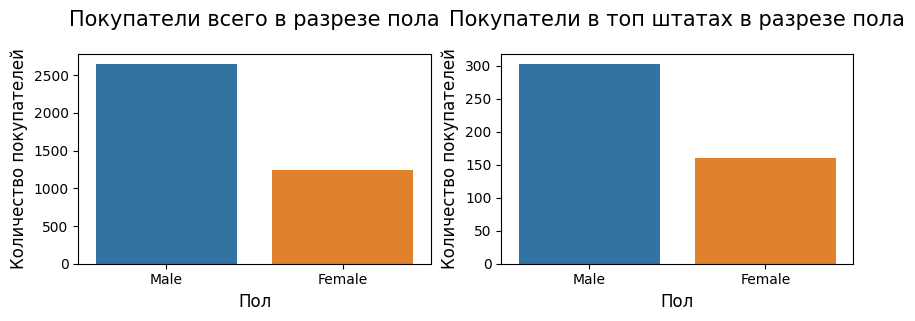

In [42]:
# Проверим гипотезу что наиболее популярные штаты имеют большую долю покупателей мужчин
top_l = ['Montana', 'California', 'Idaho', 'Illinois', 'Nevada']
mask_tl = df['Location'].isin(top_l)

# Устанавливаем размер графика
plt.figure(figsize=(10, 6))

# Рисуем график
plt.subplot(2, 2, 1)
sns.countplot(
    x='Gender',
    hue='Gender',
    data=df
    )

# Добавляем заголовок и подписи
plt.title('Покупатели всего в разрезе пола', fontsize=15, pad=20)
plt.xlabel('Пол', fontsize=12)
plt.ylabel('Количество покупателей', fontsize=12)

# Рисуем график
plt.subplot(2, 2, 2)
sns.countplot(
    x='Gender',
    hue='Gender',
    data=df[mask_tl]
    )

# Добавляем заголовок и подписи
plt.title('Покупатели в топ штатах в разрезе пола', fontsize=15, pad=20)
plt.xlabel('Пол', fontsize=12)
plt.ylabel('Количество покупателей', fontsize=12)
plt.show()

- Визуально разницы между диграммами нет - распределенение покупателей по полу не зависит от штата.

<Figure size 1000x600 with 0 Axes>

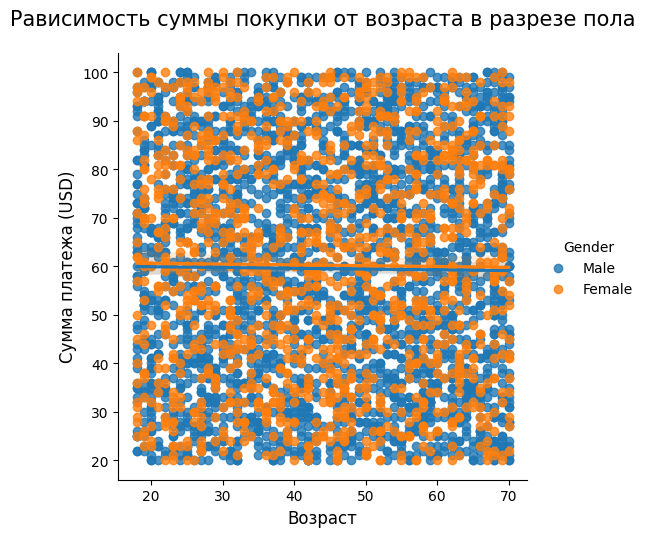

In [43]:
# Проанализируем зависимость суммы покупки от возраста
# Устанавливаем размер графика
plt.figure(figsize=(10, 6))

# Рисуем график
sns.lmplot(
    data=df,
    x='Age',
    y='Purchase Amount (USD)',
    hue='Gender'
)

# Добавляем заголовок и подписи
plt.title('Pависимость суммы покупки от возраста в разрезе пола', fontsize=15, pad=20)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Сумма платежа (USD)', fontsize=12)
plt.show()

- Зависимости стоимости покупки от возраста отсутствует.

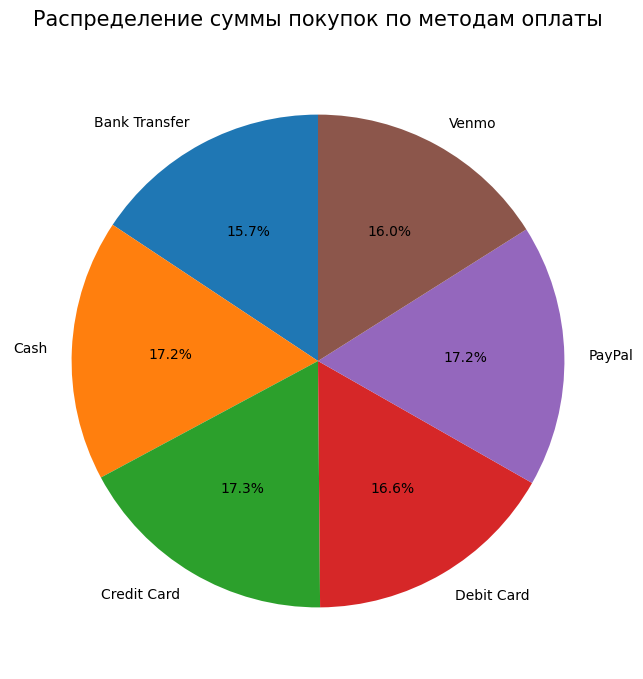

In [44]:
# Отобразим накопленную сумму покупок в зависимости от методов оплаты
# Группировка по методу оплаты и суммирование
total_by_method = df.groupby('Payment Method')['Purchase Amount (USD)'].sum()

# Создание круговой диаграммы
plt.figure(figsize=(8, 8))
plt.pie(total_by_method, labels=total_by_method.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение суммы покупок по методам оплаты', fontsize=15, pad=20)

# Отображаем диаграмму
plt.show()

- Среди способов оплаты невозможно выделить явного лидера: их доли в общем объёме транзакций примерно сопоставимы. Тем не менее, наличные, кредитные карты и PayPal используются немного чаще остальных методов.

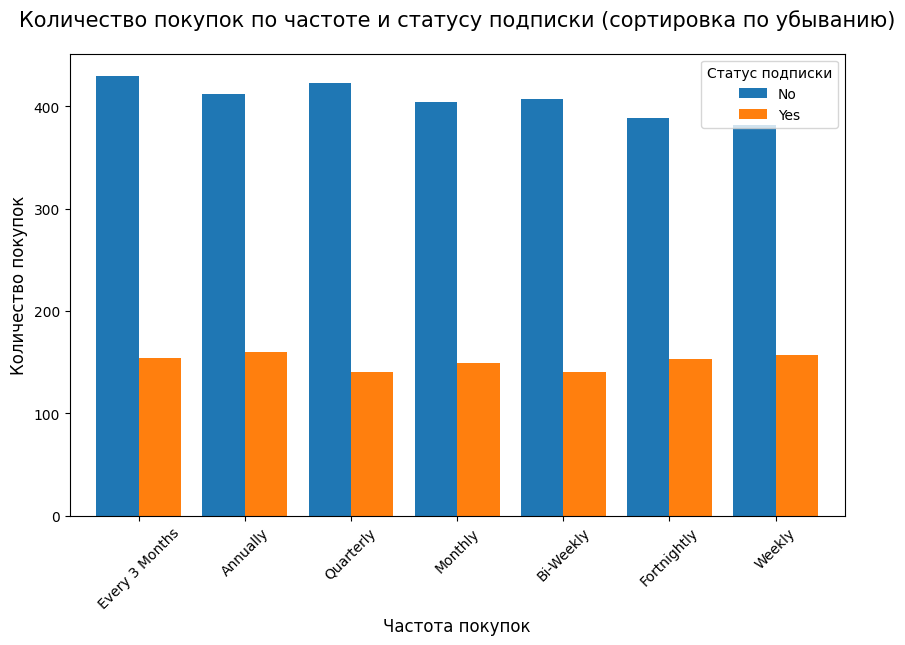

In [45]:
# Проведём анализ количества покупок по частоте и статусу подписки
# Суммарное количество покупок по 'Frequency of Purchases' для сортировки
freq_order = df.groupby('Frequency of Purchases').size().sort_values(ascending=False).index

# Группировка по 'Frequency of Purchases' и 'Subscription Status', с подсчётом
grouped = df.groupby(['Frequency of Purchases', 'Subscription Status']).size().unstack(fill_value=0)

# Сортировка по убыванию (на основе общего количества покупок)
grouped = grouped.reindex(freq_order)

# Построение столбчатой диаграммы
ax = grouped.plot(kind='bar', figsize=(10, 6), width=0.8)

# Настройка заголовка и подписей
plt.title('Количество покупок по частоте и статусу подписки (сортировка по убыванию)', fontsize=15, pad=20)
plt.xlabel('Частота покупок', fontsize=12)
plt.ylabel('Количество покупок', fontsize=12)

# Поворот меток по оси X для лучшей читаемости
plt.xticks(rotation=45)

# Легенда
plt.legend(title='Статус подписки')

# Отображение графика
plt.show()

- Покупок, совершённых без подписки, в разы больше, чем с подпиской. Это указывает на существенный потенциал для развития программы лояльности — в частности, на возможность перевода части клиентов на подписку для повышения их удержания и частоты покупок.
- На графике можно условно провести вертикальную границу, разделяющую покупателей на две группы: реже одного раза в месяц и чаще одного раза в месяц.
    - Среди клиентов с подпиской разница между группами практически неразличима — подписка, похоже, стабилизирует частоту покупок.
    - Среди клиентов без подписки чётко прослеживается убывающий тренд: больше людей совершают редкие покупки, и меньше — частые.
- Это позволяет сделать несколько предположений:
    1. Редкие покупатели, как правило, не оформляют подписку — они взаимодействуют с магазином эпизодически.
    2. Основная клиентская база — это люди, которые редко посещают район расположения магазина.
    3. Учитывая, что топовые регионы по продажам включают туристические и сельские территории, можно предположить, что значительную долю покупателей составляют:
        - Туристы, совершающие разовые покупки,
        - Жители удалённых населённых пунктов, приезжающие в магазин время от времени.
- Такая структура аудитории объясняет низкую проникновение подписки и подчёркивает необходимость гибких моделей лояльности, адаптированных под непостоянное поведение клиентов (например, временные или событийные подписки).

<Figure size 1000x600 with 0 Axes>

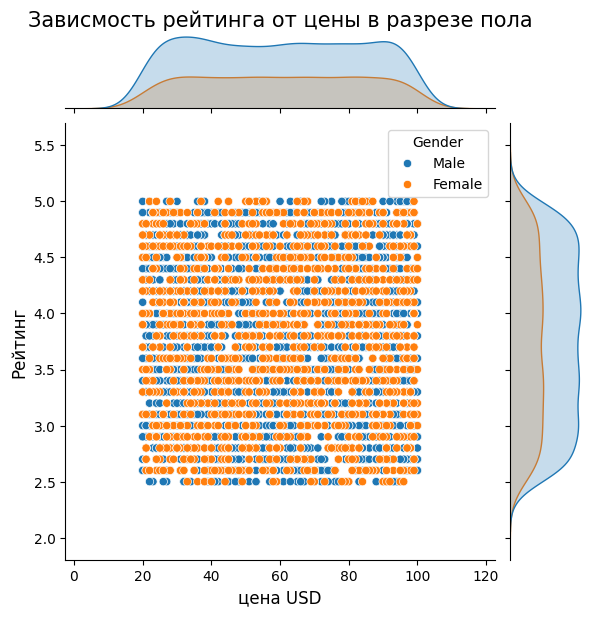

In [46]:
# Исследуем зависмость рейтинга от цены
# Устанавливаем размер графика
plt.figure(figsize=(10, 6))

# Рисуем график
sns.jointplot(
    x='Purchase Amount (USD)',
    y='Review Rating',
    hue='Gender',
    data=df
    )

# Добавляем заголовок и подписи
plt.title('Зависмость рейтинга от цены в разрезе пола', fontsize=15, pad=70)
plt.xlabel('цена USD', fontsize=12)
plt.ylabel('Рейтинг', fontsize=12)
plt.show()

- Между рейтингом товара и его ценой чёткой зависимости не наблюдается — дорогие товары не обязательно получают более высокие оценки, и наоборот.
- Распределение рейтингов имеет форму плато: оно плавно возрастает от 2,5 до 2,7, затем остаётся относительно стабильным в диапазоне от 2,7 до 4,7, и постепенно снижается от 4,7 до 5,0. Это говорит о том, что покупатели в равной степени выбирают товары с рейтингом от 2,7 до 4,7, избегая как самых низкооценённых, так и «идеальных» (максимально оценённых) позиций.
- Аналогичная картина наблюдается и для цены: распределение также напоминает плато, нарастая до 25 USD и начиная снижаться после 87 USD. Однако есть важное отличие в поведении мужчин:
    - В диапазоне от 25 до 45 USD у мужских покупок наблюдается небольшой «бугорок» — локальный рост частоты выбора товаров.
    - Это указывает на то, что в выборку попало больше товаров именно этой ценовой категории, и, следовательно, мужчины чаще предпочитают более экономичные варианты по сравнению с общей тенденцией.
- Таким образом, хотя общее распределение цен и рейтингов выглядит сбалансированным, гендерные различия проявляются в склонности мужчин к бюджетному сегменту, что может быть связано как с особенностями ассортимента, так и с потребительскими предпочтениями.

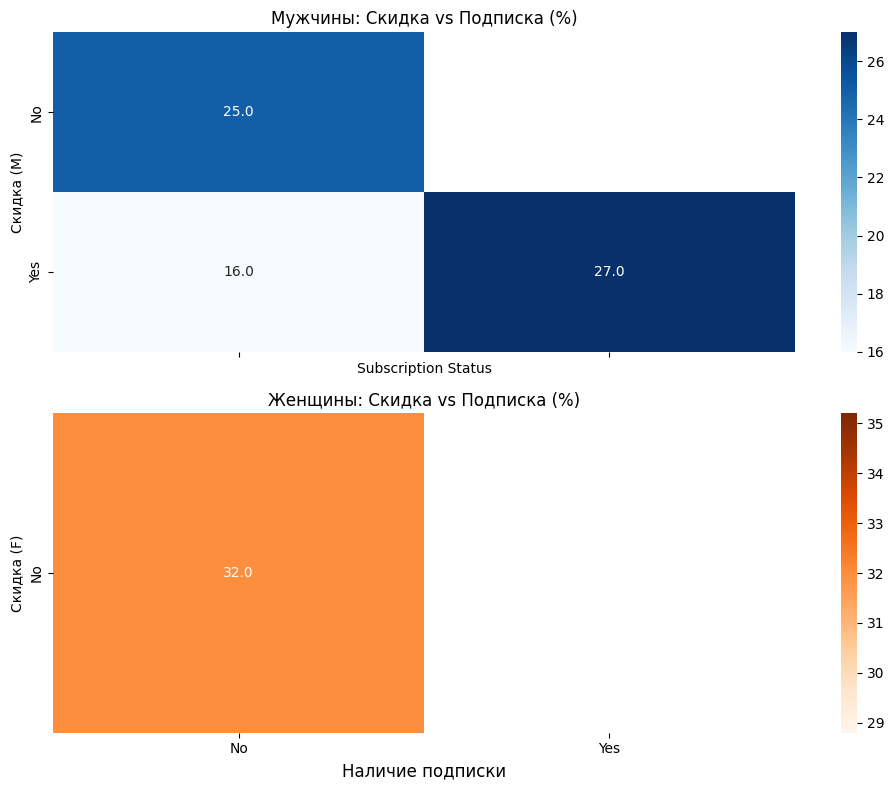

In [47]:
# Анализируем взаимосвязь подписки и использования скидки в разрезе пола
# Создаем таблицу сопряженности (нормированную)
ct_triple = df.groupby(['Gender', 'Discount Applied', 'Subscription Status']).size().unstack()
ct_triple = (ct_triple / len(df)) * 100

# Разделяем данные по полу
male_data = ct_triple.loc['Male']
female_data = ct_triple.loc['Female']

# Рисуем график
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Рисуем хитмап для мужчин (Синий)
sns.heatmap(male_data, annot=True, fmt='.1f', cmap='Blues', ax=ax1)
ax1.set_title('Мужчины: Скидка vs Подписка (%)', fontsize=12)
ax1.set_ylabel('Скидка (M)')

# Рисуем хитмап для женщин (Оранжевый)
sns.heatmap(female_data, annot=True, fmt='.1f', cmap='Oranges', ax=ax2)
ax2.set_title('Женщины: Скидка vs Подписка (%)', fontsize=12)
ax2.set_ylabel('Скидка (F)')
plt.xlabel('Наличие подписки', fontsize=12)
plt.tight_layout()
plt.show()

- Клетка, соответствующая наличию подписки и отсутствию скидки, пуста как для мужчин, так и для женщин. Это однозначно указывает на то, что подписка в системе всегда сопровождается предоставлением скидки — иными словами, подписка автоматически гарантирует скидку.
- Судя по представленным данным, в датасете отсутствуют транзакции женщин с применёными скидками, а также их покупок с наличием подписки. Это вызывает серьёзные вопросы и допускает два основных объяснения:
    1. Магазин чрезвычайно специализирован на мужскую аудиторию. Однако такой сценарий выглядит маловероятным:
        - В ассортименте присутствуют типично женские товары (блузки, платья),
        - А гендерная сегрегация такого масштаба противоречит современным нормам и может нарушать законы о равенстве в потребительской сфере.
    2. Данные неполные или искажены на этапе сбора/выгрузки.
        - На диаграмме «Покупатели всего в разрезе пола» видно, что доля женщин составляет примерно четверть от общего числа покупателей,
        - При этом демографические данные по штатам (где расположены магазины) показывают примерно равное соотношение полов — около 50 % на 50 %.
        - Следовательно, женщины с подпиской или скидкой могли быть исключены из выборки из-за ошибки фильтрации, технического сбоя или особенностей экспорта данных.

### Снижение размерности и поиск скрытых структур (PCA & t-SNE)

In [48]:
# Копируем датасет для преобразований
df_ml = df.copy()

# Gриводим к числовому виду
# Бинарные признаки 
df_ml['Gender'] = df_ml['Gender'].map({'Male': 0, 'Female': 1})
df_ml['Subscription Status'] = df_ml['Subscription Status'].map({'No': 0, 'Yes': 1})
df_ml['Discount Applied'] = df_ml['Discount Applied'].map({'No': 0, 'Yes': 1})

# Категориальные (создаем отдельные столбцы для каждой категории)
df_ml = pd.get_dummies(df_ml, columns=['Category', 'Season', 'Payment Method'], drop_first=True)

# Стандартизируем, это необходимо, чтобы признаки с разными единицами измерения вносили равный вклад в итоговый результат
scaler = StandardScaler()
# Оставляем только числовые данные для обучения
df_scaled = scaler.fit_transform(df_ml.select_dtypes(include=['number']))

In [49]:
# Создаем объект PCA, указываем 3 компоненты для 3D визуализации
pca = PCA(n_components=3)

# Обучаем и трансформируем наши стандартизированные данные (df_scaled)
pca_data = pca.fit_transform(df_scaled)

# Создаем DataFrame для визуализации
pca_df = pd.DataFrame(data=pca_data, columns=['Главная Компонента 1', 'Главная Компонента 2', 'Главная Компонента 3'])

# Приклеиваем колонки из оригинала, чтобы раскрасить точки по категориям
pca_df['Gender'] = df['Gender'].values
pca_df['Discount Applied'] = df['Discount Applied'].values

# Считаем дисперсию
total_variance = pca.explained_variance_ratio_.sum() * 100

# Визуализируем результат PCA в 3D с помощью plotly.express
fig = px.scatter_3d(
    pca_df, 
    x='Главная Компонента 1', 
    y='Главная Компонента 2', 
    z='Главная Компонента 3',
    color='Discount Applied',  # Раскрасим по наличию скидки
    symbol='Gender',   # А форма точек пусть зависит от пола
    title=f'3D PCA анализ покупателей<br>Объясненная дисперсия: {total_variance:.2f}%',
    labels={
        'Discount Applied': 'Наличие скидки', 
        'Gender': 'Пол'},
    opacity=0.7
)

# Отображаем график
fig.update_layout(margin=dict(l=0, r=0, b=0, t=50))
fig.show()

Метод главных компонент (PCA) был выбран как линейный подход к снижению размерности, поскольку он:
- сохраняет максимальную дисперсию данных при проецировании,
- обеспечивает интерпретируемость главных компонент (особенно первой, отвечающей за основную вариацию),
- позволяет объективно оценить долю сохранённой информации (в данном случае — 60,43 %),
- эффективен для выявления глобальных линейных зависимостей, что особенно актуально при анализе поведенческих признаков, таких как пол, скидка и подписка.

1. Чёткая сегментация по полу и скидке: В отличие от типичных «облаков» точек, в данном случае метод PCA смог выявить сильные линейные зависимости, которые привели к образованию четырёх чётко выраженных, параллельных сегментов покупателей:
    - Красные группы: Женщины без скидки (одна колонка) и мужчины без скидки (вторая колонка).
    - Синие группы: Две колонки с мужчинами, которые воспользовались скидкой.
2. Ключевой момент: То, что группы мужчин со скидкой и без скидки оказались разделены сильнее (по оси Главная компонента 1, отвечающей за бóльшую часть дисперсии), чем группы мужчин и женщин без скидки, говорит о том, что наличие скидки оказалось более значимым признаком для сегментации, чем пол. Это указывает на то, что поведенческие различия, связанные со скидками, доминируют над гендерными в структуре данных.
3.  Объясненная дисперсия: первые три главные компоненты сохранили 60,43 % исходной изменчивости данных — это хороший результат для трёхмерной визуализации, позволяющий уверенно интерпретировать наблюдаемые паттерны.

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3900 samples in 0.004s...
[t-SNE] Computed neighbors for 3900 samples in 0.128s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3900
[t-SNE] Computed conditional probabilities for sample 2000 / 3900
[t-SNE] Computed conditional probabilities for sample 3000 / 3900
[t-SNE] Computed conditional probabilities for sample 3900 / 3900
[t-SNE] Mean sigma: 0.575630
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.223457
[t-SNE] KL divergence after 2500 iterations: 1.125239


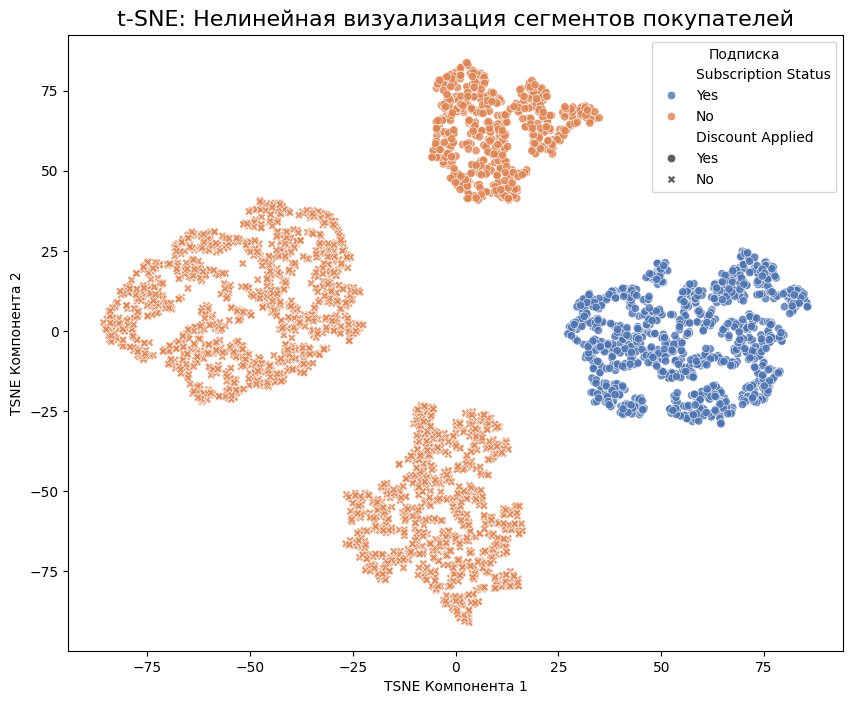

In [50]:
# Инициализируем t-SNE: 2D компоненты, 
# n_iter=2500 - количество итераций (для лучшего результата)
tsne = TSNE(n_components=2, verbose=1, random_state=42, n_iter=2500)

# Применяем к нашим отмасштабированным данным
tsne_data = tsne.fit_transform(df_scaled)

# Создаем DataFrame для визуализации
tsne_df = pd.DataFrame(data=tsne_data, columns=['TSNE1', 'TSNE2'])

# Приклеиваем нужные нам колонки из оригинала через .loc (чтобы индексы совпали)
tsne_df['Discount Applied'] = df.loc[df_ml.index, 'Discount Applied'].values
tsne_df['Subscription Status'] = df.loc[df_ml.index, 'Subscription Status'].values

# Визуализируем результат t-SNE с помощью seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1', 
    y='TSNE2', 
    hue='Subscription Status',  # Раскрасим по наличию подписки
    style='Discount Applied',          # Форма по наличию скидки
    data=tsne_df,
    palette='deep',
    alpha=0.8
)

plt.title('t-SNE: Нелинейная визуализация сегментов покупателей', fontsize=16)
plt.xlabel('TSNE Компонента 1')
plt.ylabel('TSNE Компонента 2')
plt.legend(title='Подписка', loc='best')
plt.show()

Метод t-SNE (t-Distributed Stochastic Neighbor Embedding) был выбран как нелинейный подход к снижению размерности, поскольку он:
- фокусируется на сохранении локальной структуры данных, что позволяет выявлять естественные кластеры, даже если они нелинейно разделимы;
- особенно эффективен для визуализации сложных многомерных паттернов в 2D-пространстве;
- помогает проверить устойчивость сегментов, обнаруженных линейными методами (например, PCA), за счёт иного принципа построения расстояний между точками.

1. Кластеры 1 и 3 (слева, оранжевые «X»): Это сегмент «Случайных покупателей». У них нет подписки и они не используют скидки. Этот сегмент представляет собой самую многочисленную, но наименее лояльную часть аудитории — клиенты совершают покупки эпизодически и не вовлечены в программы удержания.
2. Кластеры 2 и 4 (справа, синие круги): Это сегмент «Лояльных покупателей со скидкой». У них есть подписка и они активно пользуются скидками. Такие клиенты — наиболее активные, однако, вероятно, чувствительны к цене: их лояльность может быть обусловлена преимущественно выгодными условиями, а не эмоциональной привязанностью к бренду.

### Выводы и рекомендации по результатам исследования

Выводы по результатам анализа:
1. Магазины не специализируются на мужских товарах.
Наблюдаемое доминирование мужчин в данных, а также полное отсутствие женщин с подпиской и скидками, скорее всего, объясняется ошибкой при выгрузке данных, а не реальной бизнес-спецификой. В частности, пропущены транзакции женщин, воспользовавшихся скидками.

2. Основная аудитория — редкие покупатели, вероятно:
    - Туристы,
    - Жители удалённых населённых пунктов, редко посещающие магазин.
- Гипотезу хорошо объясняет ряд особенностей:
    - Отсутствие обуви в топе продаж: туристы предпочитают лёгкую, компактную одежду, а не объёмную обувь.
    - Высокая популярность украшений: это типичные сувениры или подарки, часто приобретаемые в поездках.
    - Покупка мужчинами блузок и платьев: скорее всего, это подарки близким.
    - Преобладание наличных и кредитных карт: в США наличные остаются популярным способом оплаты, особенно в туристических зонах; кроме того, люди часто копят деньги «на отдых» и используют их в виде cash или credit.
    - Низкая медианная цена верхней одежды и её скромное место в топе: верхняя одежда — не туристический товар, а предмет бытового спроса, поэтому она дешевле и менее востребована в данном контексте.

3. Сегментация покупателей:
- Оба метода (визуальный и PCA) чётко выделяют 4 сегмента:
    - Группа 1: женщины без скидки и подписки
    - Группа 2: мужчины без скидки и подписки
    - Группа 3: мужчины со скидкой, но без подписки
    - Группа 4: мужчины со скидкой и с подпиской
- Отсутствуют две логически ожидаемые группы:
    - женщины со скидкой без подписки,
    - женщины со скидкой и с подпиской.
- Подтверждается гипотеза о неполноте данных.
- Разделение по признаку «скидка» оказывается сильнее, чем по полу — наличие скидки является ключевым фактором поведенческой сегментации.
- Искусственная гендерная асимметрия в данных создаёт иллюзию дискриминации: если бы данные были полными, влияние пола, вероятно, стало бы менее выраженным, и фокус сместился бы на поведенческие признаки (частота, скидки, подписка).

Рекомендации:
1. Проверка качества данных.
Необходимо внедрить строгие процедуры валидации при выгрузке данных, чтобы избежать искажений, ведущих к ошибочным стратегическим решениям.

2. Развитие гибких программ лояльности.
Несмотря на неполноту данных, очевидно, что проникновение подписки крайне низкое. Рекомендуется внедрять временные, событийные или туристические подписки, ориентированные на эпизодических клиентов.

3. Оптимизация ассортимента под целевую аудиторию.
Поскольку основной покупатель — турист или редкий гость, следует:
    - Увеличить долю лёгкой одежды и аксессуаров (сувениров),
    - Скорректировать сезонный ассортимент,
    - Снизить акцент на обуви и верхней одежде, которые мало востребованы в этом контексте.

4. Дифференциация магазинов (при наличии сети).
Если в штате несколько точек, их можно специализировать:
    - Одни — на туристический поток (аксессуары, подарки, яркие вещи),
    - Другие — на местных жителей (базовая одежда, верхняя одежда, практичные товары).

5. Поддержка наличных платежей.
Цифровизация не должна идти в ущерб консервативным клиентам. Наличные остаются важным каналом оплаты, особенно в регионах с высоким туристическим потоком.

6. Скидки как ключевой стимул.
- Тепловая карта, наиболее полных данных по покупкам мужчин, показывает: только 25 % товаров продаются без скидки. Скидки — не просто маркетинговый инструмент, а основной драйвер вовлечённости, особенно для:
    - Привлечения редких покупателей,
    - Стимулирования перехода на подписку.
- Рекомендуется усилить связку «скидка - подписка» и использовать скидки как «крючок» для вовлечения.
